# Overview

In this project, you will implement a scaled-down version of OpenAI's GPT-2 architecture from scratch using PyTorch. You'll train this model on the Snappfood comments with sentiment labels. The goal is to create a generative language model that can produce synthetic Persian comments with controllable sentiment (positive or negative).

# Learning Objectives

* Understanding and implementing transformer-based language model architectures  
* Learning how to control text generation using special tokens  
* Visualizing and analyzing training progress  

# Dataset

You'll work with a Persian dataset containing Snappfood comments:  

* The dataset texts are normalized (No need for any normalizations)
* Each comment has a sentiment label (1 for positive, 0 for negative)
* The dataset contains text with variations in length and style

# Tokenizer and model

You should use one of the sota open-source LLM tokenizers. I strongly recommend using Llama 3.3 tokenizer or Gemma-2 tokenizer as they're better than the others in Persian language. (There is no need to implement a tokenizer yourself.)

Your model should have the exact srtructure of GPT-2:  
  
<img src="GPT-2.png" alt="" width="600" height="800">
  
For the model to be able to smoothly be trained, you should use the config below:

* **Embedding Dimension**: 192 (reduced from 768 in original GPT-2)
* **Layers**: 3 transformer blocks (reduced from 12 in original GPT-2)
* **Attention Heads**: 3 (reduced from 12 in original GPT-2)
* **Context Window**: 128 tokens (reduced from 1024 in original GPT-2)

Moreover, unlike the original Transformer paper that used fixed sinusoidal position encodings, GPT-2 (and your implementation) should use learnable position embeddings:
1. You should create an embedding table of size [n_positions, n_embd] where:

    * n_positions is the maximum sequence length (128 in our model)
    * n_embd is the embedding dimension (192 in our model)
2. For each position in the sequence (0 to sequence_length-1), we look up the corresponding embedding vector.

3. These position embeddings are added to the token embeddings before being passed through the transformer blocks.

# Some notes:

* Be aware that you will be questioned about your solution to this assignment in-person. Thus, build a solid understanding through out solving this assignment.
* Using ChatGPT and other LLMs are allowed but you should be able to explain every line of your code completely.
* You need GPU for this assignment. Use can use Colab or Kaggle for free.
* I highly recommend using the exact same structure and instructions that is provided for you in the notebook but minor changes will be tolerated.
* Read the whole notebook once before coding. It will give you a broad vision about what you should do on the whole.
* Instructions provided for you in TODO sections ARE NOT the only things that you should do in those parts. They're just some important bullet points that your code should have.
* The final results (Inference section) should have the minimum quality of the samples already generated in the notebook.

# Importing

In [21]:
# Data loading and manipulation
import kagglehub
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Tokenization utilities
from transformers import AutoTokenizer
from huggingface_hub import login

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Visualization tool
import matplotlib.pyplot as plt

# Runtime utilities
import math
import time
from tqdm.auto import tqdm

# Downloading and loading the data

In this section we read and load the data from [here](https://www.kaggle.com/datasets/mohammad1ziyar/cleaned-snappfood-persian-sentiment-analysis).

You can also see some information about the data in the next cell. In the end, we only want the label and cleaned columns.

In [22]:
path = kagglehub.dataset_download("mohammad1ziyar/cleaned-snappfood-persian-sentiment-analysis")

print("Path to dataset files:", path)

raw_corpus = pd.read_csv(path + "/cleaned_snappfood.csv")

Using Colab cache for faster access to the 'cleaned-snappfood-persian-sentiment-analysis' dataset.
Path to dataset files: /kaggle/input/cleaned-snappfood-persian-sentiment-analysis


In [23]:
raw_corpus.info()
raw_corpus.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65973 entries, 0 to 65972
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   comment          65973 non-null  object
 1   label            65973 non-null  int64 
 2   comment_length   65973 non-null  int64 
 3   comment_cleaned  65973 non-null  object
dtypes: int64(2), object(2)
memory usage: 2.0+ MB


,comment,label,comment_length,comment_cleaned
0,واقعا حیف وقت که بنویسم سرویس دهیتون شده افتضاح,0,47,واقعا حیف وقت که بنویسم سرویس دهیتون شده افتضاح
1,قرار بود ۱ ساعته برسه ولی نیم ساعت زودتر از مو...,1,132,قرار بود ساعته برسه ولی نیم ساعت زودتر از موق...
2,قیمت این مدل اصلا با کیفیتش سازگاری نداره، فقط...,0,89,قیمت این مدل اصلا با کیفیتش سازگاری نداره فقط ...
3,عالی بود همه چه درست و به اندازه و کیفیت خوب، ...,1,99,عالی بود همه چه درست و به اندازه و کیفیت خوب ا...
4,شیرینی وانیلی فقط یک مدل بود.,1,29,شیرینی وانیلی فقط یک مدل بود


In [24]:
raw_corpus = raw_corpus[["comment_cleaned", "label"]]

# Downloading and loading the tokenizer (5 Points)

In this section you need to load your tokenizer from hugging face. I recommend [this](https://huggingface.co/meta-llama/Llama-3.3-70B-Instruct) or [this](https://huggingface.co/google/gemma-2-27b-it).
Keep in mind that you might need to login first using your hugging face access token and also sign an agreement thing in model's page to be able to access the model and it's tokenizer.

In [ ]:
login(token = 'HF_TOKEN')
tokenizer = AutoTokenizer.from_pretrained("google/gemma-2-27b-it")

In the cell below, add two special tokens to the vocabulary of the tokenizer indicating positivity or negativity of a comment. We will add these tokens manually as the first token of each comment so model will understand the difference between positive and negative comments.

In [26]:
special_tokens = {
    'additional_special_tokens': ['<POSITIVE>', '<NEGATIVE>']
}
tokenizer.add_special_tokens(special_tokens)

2

In [27]:
tokenizer.convert_ids_to_tokens(2)

'<bos>'

## Dataset and Dataloader (10 Points)

Create a custom Dataset class for the data

In [28]:
class CommentDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=128):
        self.tokenizer = tokenizer
        self.comments = dataframe['comment_cleaned'].tolist()
        self.labels = dataframe['label'].tolist()
        self.max_length = max_length

    def __len__(self):
        return len(self.comments)

    def __getitem__(self, idx):
        label = self.labels[idx]
        comment = self.comments[idx]

        # Prefix token based on sentiment
        prefix_token = "<POSITIVE>" if label == 1 else "<NEGATIVE>"
        prefix_id = self.tokenizer.convert_tokens_to_ids(prefix_token)

        # Tokenize the comment
        tokens = self.tokenizer.encode(comment, truncation=True, max_length=self.max_length)

        # Combine prefix + tokens
        input_ids = [prefix_id] + tokens
        attention_mask = [1] * len(input_ids)

        # Pad if necessary
        if len(input_ids) < self.max_length:
            pad_length = self.max_length - len(input_ids)
            input_ids += [self.tokenizer.pad_token_id] * pad_length
            attention_mask += [0] * pad_length

        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "attention_mask": torch.tensor(attention_mask, dtype=torch.long),
            "labels": torch.tensor(input_ids, dtype=torch.long)
        }


Create train and validation datasets and dataloaders and also split the data

In [29]:
# TODO: Prepare the training and validation datasets and dataloaders
#
# 1. Split the raw_corpus dataframe into training and validation sets with a suitable ratio
# 2. Create dataset instances using the CommentDataset class:
# 3. Create DataLoader instances
indices = np.random.permutation(len(raw_corpus))
train_size = int(len(indices) * 0.95)
val_size = len(indices) - train_size
shuffled = raw_corpus.iloc[indices]
train_ds = shuffled[:train_size]
val_ds = shuffled[train_size:]

train_dataset = CommentDataset(train_ds, tokenizer)
val_dataset = CommentDataset(val_ds, tokenizer)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(train_dataset, batch_size=4, shuffle=False)

## Model implementation (35 Points)

In this section you should implement the model architecture completely from scratch. No pre-defined torch or other libraries tools are allowed. (Even for the attention mechanism)

In [30]:
class GPT2Config:
    def __init__(
        self,
        vocab_size,
        n_positions,
        n_embd,
        n_layer,
        n_head,
        n_inner=None,
        activation_function="gelu",
        resid_pdrop=0.1,
        embd_pdrop=0.1,
        attn_pdrop=0.1,
        layer_norm_epsilon=1e-5,
        initializer_range=0.02,
        bos_token_id=None,
        eos_token_id=None,
    ):
        self.vocab_size = vocab_size
        self.n_positions = n_positions
        self.n_embd = n_embd
        self.n_layer = n_layer
        self.n_head = n_head
        self.n_inner = 4 * n_embd if n_inner is None else n_inner
        self.activation_function = activation_function
        self.resid_pdrop = resid_pdrop
        self.embd_pdrop = embd_pdrop
        self.attn_pdrop = attn_pdrop
        self.layer_norm_epsilon = layer_norm_epsilon
        self.initializer_range = initializer_range
        self.bos_token_id = bos_token_id
        self.eos_token_id = eos_token_id

In [31]:
class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.dropout = nn.Dropout(config.attn_pdrop)

        self.c_attn = nn.Linear(self.n_embd, 3 * self.n_embd)
        self.c_proj = nn.Linear(self.n_embd, self.n_embd)

        # Causal mask for attention
        mask = torch.tril(torch.ones(config.n_positions, config.n_positions)).view(1, 1, config.n_positions, config.n_positions)
        self.register_buffer("mask", mask)

    def forward(self, x):
        B, T, C = x.size()
        head_dim = C // self.n_head
        assert head_dim * self.n_head == C, "Embedding not divisible by number of heads"

        # 1. Linear projection
        qkv = self.c_attn(x)  # (B, T, 3*C)
        q, k, v = qkv.chunk(3, dim=2)

        # 2. Reshape for multi-head: (B, n_head, T, head_dim)
        q = q.view(B, T, self.n_head, head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_head, head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_head, head_dim).transpose(1, 2)

        # 3. Scaled dot-product attention
        attn_score = (q @ k.transpose(-2, -1)) / math.sqrt(head_dim)

        # Apply causal mask
        attn_score = attn_score.masked_fill(self.mask[:, :, :T, :T] == 0, float('-inf'))

        attn_probs = F.softmax(attn_score, dim=-1)
        attn_probs = self.dropout(attn_probs)

        # 4. Attention output
        attn_out = attn_probs @ v
        attn_out = attn_out.transpose(1, 2).contiguous().view(B, T, C)

        # 5. Output projection + residual
        return self.c_proj(attn_out) + x


In [32]:
class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc = nn.Linear(config.n_embd, config.n_inner)
        self.c_proj = nn.Linear(config.n_inner, config.n_embd)
        self.dropout = nn.Dropout(config.resid_pdrop)

    def forward(self, x):
        # Feed-forward network with GELU activation
        out = F.gelu(self.c_fc(x))
        out = self.dropout(self.c_proj(out))
        return x + out  # Residual connection


In [33]:
class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        # LayerNorm before attention and MLP (pre-norm)
        self.ln_1 = nn.LayerNorm(config.n_embd, eps=config.layer_norm_epsilon)
        self.ln_2 = nn.LayerNorm(config.n_embd, eps=config.layer_norm_epsilon)

        # Causal self-attention
        self.attn = CausalSelfAttention(config)

        # Feed-forward network
        self.mlp = MLP(config)

    def forward(self, x):
        # 1. Attention block with residual
        x = x + self.attn(self.ln_1(x))

        # 2. Feed-forward block with residual
        x = x + self.mlp(self.ln_2(x))

        return x


In [34]:
class GPT2(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config

        self.transformer = nn.ModuleDict({
            'wte': nn.Embedding(config.vocab_size, config.n_embd),
            'wpe': nn.Embedding(config.n_positions, config.n_embd),
            'drop': nn.Dropout(config.embd_pdrop),
            'h': nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            'ln_f': nn.LayerNorm(config.n_embd, eps=config.layer_norm_epsilon)
        })

        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.transformer['wte'].weight = self.lm_head.weight

        self.apply(self._init_weights)

    def _init_weights(self, module):
        # 1. For Linear and Embedding layers:
        #    - Initialize weights from a normal distribution with mean=0.0 and
        #      std=self.config.initializer_range
        #    - For Linear layers with bias, initialize the bias to zero
        # 2. For LayerNorm layers:
        #    - Initialize bias to zero
        #    - Initialize weight to ones
        if isinstance(module, (nn.Linear, nn.Embedding)):
            module.weight.data.normal_(mean=0.0, std=self.config.initializer_range)
            if isinstance(module, nn.Linear) and module.bias is not None:
                module.bias.data.zero_()
        elif isinstance(module, nn.LayerNorm):
            module.bias.data.zero_()
            module.weight.data.fill_(1.0)

    def forward(self, input_ids, attention_mask=None, labels=None):
        #
        device = input_ids.device
        b, t = input_ids.size()

        # 1. Create position indices
        pos = torch.arange(0, t, dtype=torch.long, device=device).unsqueeze(0)

        # 2. Compute embeddings
        token_embeddings = self.transformer['wte'](input_ids)
        position_embeddings = self.transformer['wpe'](pos)

        # 3. Process the input through transformer blocks
        x = self.transformer['drop'](token_embeddings + position_embeddings)
        for block in self.transformer['h']:
            x = block(x)

        # 4. Apply final layer normalization
        x = self.transformer['ln_f'](x)

        # 5. Compute logits using the language model head
        logits = self.lm_head(x)

        # 6. Return a dictionary with 'logits' and 'loss' (if calculated)
        loss = None
        if labels is not None:
            shift_logits = logits[..., :-1, :].contiguous()
            shift_labels = labels[..., 1:].contiguous()

            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(shift_logits.view(-1, shift_logits.size(-1)),
                            shift_labels.view(-1))

        return {'logits': logits, 'loss': loss}

    def generate(self, input_ids, max_length, temperature=1.0, top_k=0, top_p=0.9):
        # This method should generate text auto-regressively using the trained model
        # with temperature, top-k, and nucleus (top-p) sampling techniques.
        #
        # 1. Set the model to evaluation mode
        self.eval()
        with torch.no_grad():
            # 2. Loop to generate 'max_length' new tokens:
            for _ in range(max_length):
                #    a. Run the forward pass to get logits for the current sequence
                outputs = self(input_ids)
                logits = outputs['logits']
                #    b. Extract logits for the last token and apply temperature scaling        #
                next_token_logits = logits[:, -1, :] / temperature

                #    c. Apply top-k sampling if top_k > 0:
                if top_k > 0:
                    values, _ = torch.topk(next_token_logits, top_k)
                    next_token_logits[next_token_logits < values[:, [-1]]] = -float('inf')

                #    d. Apply nucleus (top-p) sampling if top_p < 1.0:
                if top_p < 1.0:
                    sorted_logits, sorted_indices = torch.sort(next_token_logits, descending=True)
                    cumulative_probs = torch.cumsum(F.softmax(sorted_logits, dim=-1), dim=-1)

                    sorted_indices_to_remove = cumulative_probs > top_p

                    sorted_indices_to_remove[..., 1:] = sorted_indices_to_remove[..., :-1].clone()
                    sorted_indices_to_remove[..., 0] = 0

                    indices_to_remove = sorted_indices_to_remove.scatter(1, sorted_indices, sorted_indices_to_remove)
                    next_token_logits[indices_to_remove] = -float('inf')

                # 3. Return the complete generated sequence
                probs = F.softmax(next_token_logits, dim=-1)
                next_token = torch.multinomial(probs, num_samples=1)

                input_ids = torch.cat([input_ids, next_token], dim=1)

                if next_token.item() == tokenizer.eos_token_id:
                    break

        return input_ids

## Train and evaluation (25 Points)

Now you should implement the train and evaluation functions.

In [35]:
def train_epoch(model, data_loader, optimizer, scheduler, device, log_interval):
    model.train()
    total_loss = 0
    progress_bar = tqdm(data_loader, desc="Training")
    step_losses = []
    step_nums = []
    step = 0

    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs['loss']

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        step += 1
        if step % log_interval == 0:
            step_losses.append(loss.item())
            step_nums.append(step)

        total_loss += loss.item()
        progress_bar.set_postfix({'loss': loss.item()})

    return total_loss / len(data_loader), step_nums, step_losses

def evaluate(model, data_loader, device, log_interval):
    model.eval()
    total_loss = 0
    step_losses = []
    step_nums = []
    step = 0

    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs['loss']

            step += 1
            if step % log_interval == 0:
                step_losses.append(loss.item())
                step_nums.append(step)

            total_loss += loss.item()

    return total_loss / len(data_loader), step_nums, step_losses

In [36]:
config = GPT2Config(
    vocab_size=len(tokenizer),
    n_positions=128,
    n_embd=192,
    n_layer=3,
    n_head=3,
    bos_token_id=tokenizer.bos_token_id,
    eos_token_id=tokenizer.eos_token_id
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = GPT2(config)
model.to(device)

GPT2(
  (transformer): ModuleDict(
    (wte): Embedding(256002, 192)
    (wpe): Embedding(128, 192)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-2): 3 x Block(
        (ln_1): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
        (ln_2): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
        (attn): CausalSelfAttention(
          (dropout): Dropout(p=0.1, inplace=False)
          (c_attn): Linear(in_features=192, out_features=576, bias=True)
          (c_proj): Linear(in_features=192, out_features=192, bias=True)
        )
        (mlp): MLP(
          (c_fc): Linear(in_features=192, out_features=768, bias=True)
          (c_proj): Linear(in_features=768, out_features=192, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=192, out_features=256002, bias=False)
)

Now train the model for 3 to 5 epochs. It's recommended to use a good learning rate scheduler (For example, cosine). Also save training and validation loss periodically.

In [37]:
epochs = 5


optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.01)
total_steps = len(train_loader) * epochs
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_steps)

epoch_train_losses = []
epoch_val_losses = []
all_train_step_losses = []
all_train_step_nums = []
all_val_step_losses = []
all_val_step_nums = []

# Implement the main training loop:
#    For each epoch:
#       - Call train_epoch to train for one epoch and get losses and step information
#       - Store the average epoch loss in epoch_train_losses
#       - Update step tracking, adjusting step numbers for the current epoch
#       - Call evaluate to validate the model and get validation losses
#       - Store the average validation loss in epoch_val_losses
#       - Update validation step tracking
#       - Print the training and validation losses for the epoch

best_val_loss = float('inf')
for epoch in range(epochs):
    print(f"Epoch {epoch+1}")

    train_loss, train_step_nums, train_step_losses = train_epoch(
        model, train_loader, optimizer, scheduler, device, log_interval=100
    )
    epoch_train_losses.append(train_loss)

    epoch_offset = epoch * len(train_loader)
    all_train_step_nums.extend([n + epoch_offset for n in train_step_nums])
    all_train_step_losses.extend(train_step_losses)

    val_loss, val_step_nums, val_step_losses = evaluate(
        model, val_loader, device, log_interval=100
    )
    epoch_val_losses.append(val_loss)

    epoch_val_offset = epoch * len(val_loader)
    all_val_step_nums.extend([n + epoch_val_offset for n in val_step_nums])
    all_val_step_losses.extend(val_step_losses)

    print(f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "gpt2_persian_comments.pt")
        print("Saved best model!")

Epoch 1


Training:   0%|          | 0/7835 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/15669 [00:00<?, ?it/s]

Train Loss: 1.2617, Val Loss: 0.8374
Saved best model!
Epoch 2


Training:   0%|          | 0/7835 [00:00<?, ?it/s]

...

Training:   0%|          | 0/7835 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/15669 [00:00<?, ?it/s]

Train Loss: 0.7612, Val Loss: 0.7460
Saved best model!
Epoch 5


Training:   0%|          | 0/7835 [00:00<?, ?it/s]

KeyboardInterrupt: 

Plot the training and validation loss in each epoch and also in each steps you saved before.

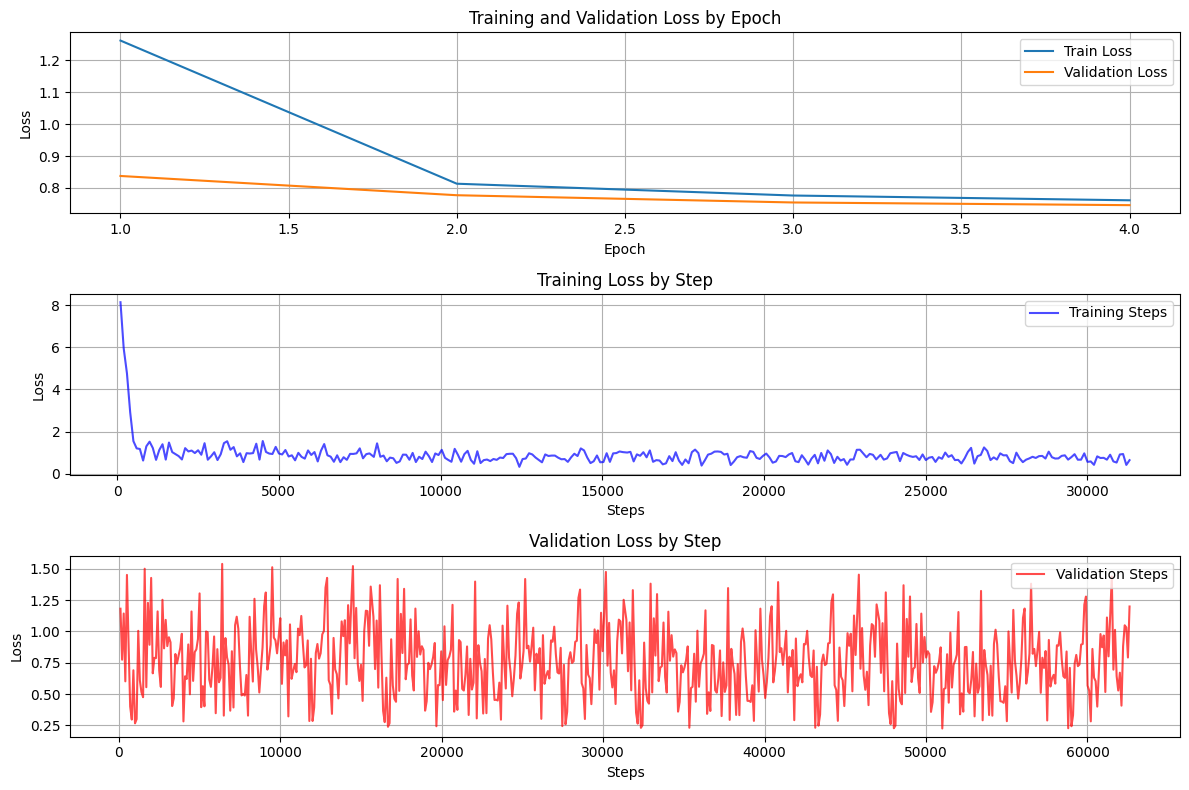

In [38]:
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(range(1, len(epoch_train_losses) + 1), epoch_train_losses, label='Train Loss')
plt.plot(range(1, len(epoch_val_losses) + 1), epoch_val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss by Epoch')
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(all_train_step_nums, all_train_step_losses, 'b-', alpha=0.7, label='Training Steps')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Training Loss by Step')
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(all_val_step_nums, all_val_step_losses, 'r-', alpha=0.7, label='Validation Steps')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Validation Loss by Step')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Inference (15 Points)

Complete the function below to generate comments (positive or negative)

In [39]:
def generate_comment(model, tokenizer, sentiment, max_length=50):
    prefix = '<POSITIVE>' if sentiment == 'positive' else '<NEGATIVE>'
    input_ids = tokenizer.encode(prefix, return_tensors='pt').to(device)

    output_ids = model.generate(
        input_ids=input_ids,
        max_length=max_length,
        temperature=0.7,
        top_k=40,
        top_p=0.92
    )

    generated_text = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    return generated_text

Generate 20 positive and 20 negative comments and evaluate your results

In [43]:
model.eval()

for _ in range(10):
    print("Positive Comment:")
    print(generate_comment(model, tokenizer, 'positive', 100))
    print("\nNegative Comment:")
    print(generate_comment(model, tokenizer, 'negative', 100))
    print()

Positive Comment:


AcceleratorError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


## Inference Time Hyperparameters (10 Points)

Play with these parameters for the best results:
  
temperature, top_k, top_p

Briefly report what you saw and try to explain why is it happening. What is the effect of each one?

**Your Report**:  
Temperature: Controls randomness in the token selection process. Higher values (>1.0) increases randomness, producing more diverse but potentially less coherent text. Lower values (<1.0) makes generation more deterministic and focused, but potentially repetitive.  
Top-k Sampling: Restricts token selection to only the k most likely candidates. Higher values allow more diversity in generation but may include less probable tokens. Lower values keep generation more focused on likely outcomes.  
Top-p (Nucleus) Sampling: Selects the smallest set of tokens whose cumulative probability exceeds p. Higher values (closer to 1) include more tokens, allowing more diversity. Lower values (closer to 0) restrict to only the most likely tokens. It's advantage over top-k is that it adapts based on the confidence of the model's predictions.